# RFM Customer Segmentation — Online Retail

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

## Load & clean data (same rules as main analysis)

In [3]:
df = pd.read_excel("Online Retail.xlsx")

df_clean = (
    df.drop_duplicates()
    .dropna(subset=["CustomerID", "Description"])
    .loc[lambda d: ~d["InvoiceNo"].astype(str).str.startswith("C")]
    .loc[lambda d: d["Quantity"] > 0]
    .loc[lambda d: d["UnitPrice"] > 0]
    .copy()
)

df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean["CustomerID"] = df_clean["CustomerID"].astype("Int64")
df_clean = df_clean.reset_index(drop=True)

print(f"Line items: {len(df_clean):,}")
print(f"Unique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Date range: {df_clean['InvoiceDate'].min()} → {df_clean['InvoiceDate'].max()}")

Line items: 392,692
Unique customers: 4,338
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


## Build customer-level RFM metrics

In [4]:
# Reference date = day after last transaction (standard RFM recency anchor)
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# One row per order (invoice)
orders = (
    df_clean.groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        Order_Date=("InvoiceDate", "max"),
        Order_Revenue=("Revenue", "sum"),
    )
)

# One row per customer
rfm = (
    orders.groupby("CustomerID")
    .agg(
        Recency=("Order_Date", lambda x: (snapshot_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Order_Revenue", "sum"),
    )
    .reset_index()
)

rfm["Avg_Order_Value"] = rfm["Monetary"] / rfm["Frequency"]
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value
0,12346,326,1,77183.60,77183.600000
1,12347,2,7,4310.00,615.714286
2,12348,75,4,1797.24,449.310000
3,12349,19,1,1757.55,1757.550000
4,12350,310,1,334.40,334.400000
5,12352,36,8,2506.04,313.255000
6,12353,204,1,89.00,89.000000
7,12354,232,1,1079.40,1079.400000
8,12355,214,1,459.40,459.400000
9,12356,23,3,2811.43,937.143333


## Score R, F, M (quintiles 1–5; higher = better)

In [5]:
rfm_scored = rfm.copy()

# Recency: lower days = better → reverse quintile
rfm_scored["R_Score"] = pd.qcut(
    rfm_scored["Recency"], q=5, labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency & Monetary: higher = better
rfm_scored["F_Score"] = pd.qcut(
    rfm_scored["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm_scored["M_Score"] = pd.qcut(
    rfm_scored["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
).astype(int)

rfm_scored["RFM_Score"] = (
    rfm_scored["R_Score"].astype(str)
    + rfm_scored["F_Score"].astype(str)
    + rfm_scored["M_Score"].astype(str)
)

rfm_scored["RFM_Sum"] = rfm_scored["R_Score"] + rfm_scored["F_Score"] + rfm_scored["M_Score"]

display(rfm_scored.describe())
rfm_scored.head(10)

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,R_Score,F_Score,M_Score,RFM_Sum
count,4338.0,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.00000,4338.00000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081,417.645735,3.015445,3.00000,3.00000,9.015445
std,1721.808492,100.014169,7.697998,8985.230220,1796.511343,1.414537,1.41454,1.41454,3.590394
min,12346.0,1.000000,1.000000,3.750000,3.450000,1.000000,1.00000,1.00000,3.000000
25%,13813.25,18.000000,1.000000,306.482500,177.867083,2.000000,2.00000,2.00000,6.000000
50%,15299.5,51.000000,2.000000,668.570000,291.940000,3.000000,3.00000,3.00000,9.000000
75%,16778.75,142.000000,5.000000,1660.597500,428.280625,4.000000,4.00000,4.00000,12.000000
max,18287.0,374.000000,209.000000,280206.020000,84236.250000,5.000000,5.00000,5.00000,15.000000


,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum
0,12346,326,1,77183.60,77183.600000,1,1,5,115,7
1,12347,2,7,4310.00,615.714286,5,5,5,555,15
2,12348,75,4,1797.24,449.310000,2,4,4,244,10
3,12349,19,1,1757.55,1757.550000,4,1,4,414,9
4,12350,310,1,334.40,334.400000,1,1,2,112,4
5,12352,36,8,2506.04,313.255000,3,5,5,355,13
6,12353,204,1,89.00,89.000000,1,1,1,111,3
7,12354,232,1,1079.40,1079.400000,1,1,4,114,6
8,12355,214,1,459.40,459.400000,1,1,2,112,4
9,12356,23,3,2811.43,937.143333,4,3,5,435,12


## Assign customer segments

In [6]:
def assign_rfm_segment(row):
    """Map R/F/M scores to a named segment."""
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    if r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    if r >= 4 and f <= 2:
        return "Recent Customers"
    if r >= 3 and f <= 2 and m >= 3:
        return "Potential Loyalists"
    if r >= 3 and f <= 2 and m <= 2:
        return "Promising"
    if r == 3 and f <= 2:
        return "Need Attention"
    if r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    if r <= 2 and f >= 4 and m >= 4:
        return "Cant Lose Them"
    if r <= 2 and f <= 2 and m >= 3:
        return "Hibernating"
    if r <= 2 and f <= 2 and m <= 2:
        return "Lost"
    return "Others"


rfm_scored["Segment"] = rfm_scored.apply(assign_rfm_segment, axis=1)

segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "Recent Customers",
    "Promising",
    "Need Attention",
    "Cant Lose Them",
    "At Risk",
    "Hibernating",
    "Lost",
    "Others",
]
rfm_scored["Segment"] = pd.Categorical(
    rfm_scored["Segment"], categories=segment_order, ordered=True
)

rfm_scored.head(10)

,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum,Segment
0,12346,326,1,77183.60,77183.600000,1,1,5,115,7,Hibernating
1,12347,2,7,4310.00,615.714286,5,5,5,555,15,Champions
2,12348,75,4,1797.24,449.310000,2,4,4,244,10,At Risk
3,12349,19,1,1757.55,1757.550000,4,1,4,414,9,Recent Customers
4,12350,310,1,334.40,334.400000,1,1,2,112,4,Lost
5,12352,36,8,2506.04,313.255000,3,5,5,355,13,Loyal Customers
6,12353,204,1,89.00,89.000000,1,1,1,111,3,Lost
7,12354,232,1,1079.40,1079.400000,1,1,4,114,6,Hibernating
8,12355,214,1,459.40,459.400000,1,1,2,112,4,Lost
9,12356,23,3,2811.43,937.143333,4,3,5,435,12,Loyal Customers


## Segment summary

In [7]:
segment_summary = (
    rfm_scored.groupby("Segment", observed=False)
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency_Days=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum"),
    )
    .reset_index()
)

total_customers = segment_summary["Customers"].sum()
total_revenue = segment_summary["Total_Revenue"].sum()

segment_summary["Pct_Customers"] = (
    segment_summary["Customers"] / total_customers * 100
).round(2)
segment_summary["Pct_Revenue"] = (
    segment_summary["Total_Revenue"] / total_revenue * 100
).round(2)
segment_summary = segment_summary.sort_values("Total_Revenue", ascending=False)

display(segment_summary)

,Segment,Customers,Avg_Recency_Days,Avg_Frequency,Avg_Monetary,Total_Revenue,Pct_Customers,Pct_Revenue
0,Champions,957,12.824451,11.123302,6051.871202,5791640.740,22.06,65.17
1,Loyal Customers,764,35.685864,4.115183,1827.896808,1396513.161,17.61,15.71
7,At Risk,453,141.613687,3.807947,1632.400775,739477.551,10.44,8.32
8,Hibernating,244,183.495902,1.299180,1355.297791,330692.661,5.62,3.72
9,Lost,821,228.121803,1.042631,228.537748,187629.491,18.93,2.11
3,Recent Customers,319,18.517241,1.241379,455.234295,145219.740,7.35,1.63
10,Others,429,95.540793,2.426573,314.516177,134927.440,9.89,1.52
2,Potential Loyalists,101,53.940594,1.396040,969.512079,97920.720,2.33,1.10
4,Promising,250,53.328000,1.068000,252.749560,63187.390,5.76,0.71
6,Cant Lose Them,0,NaN,NaN,NaN,0.000,0.0,0.00


## Visualizations

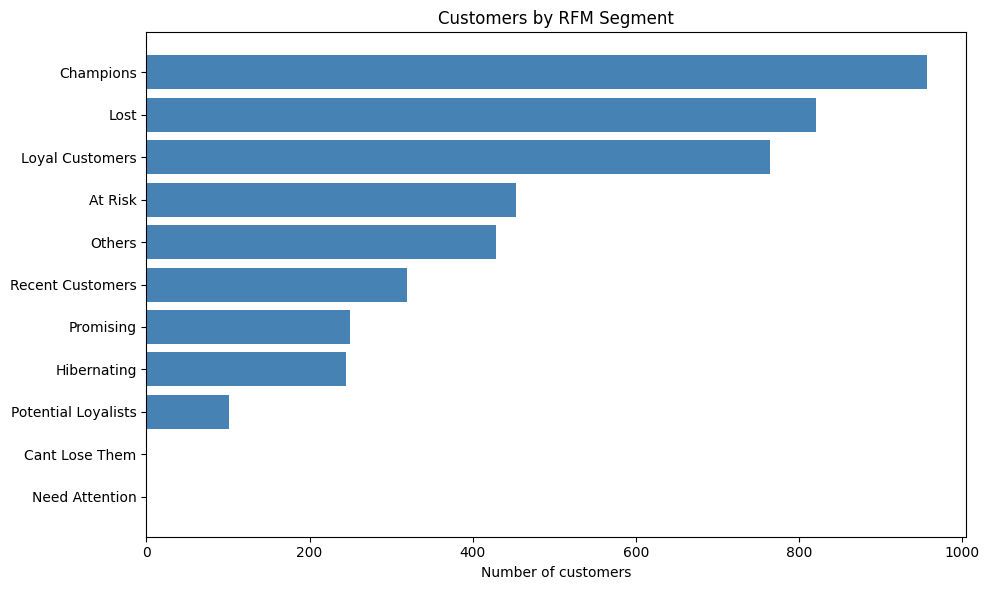

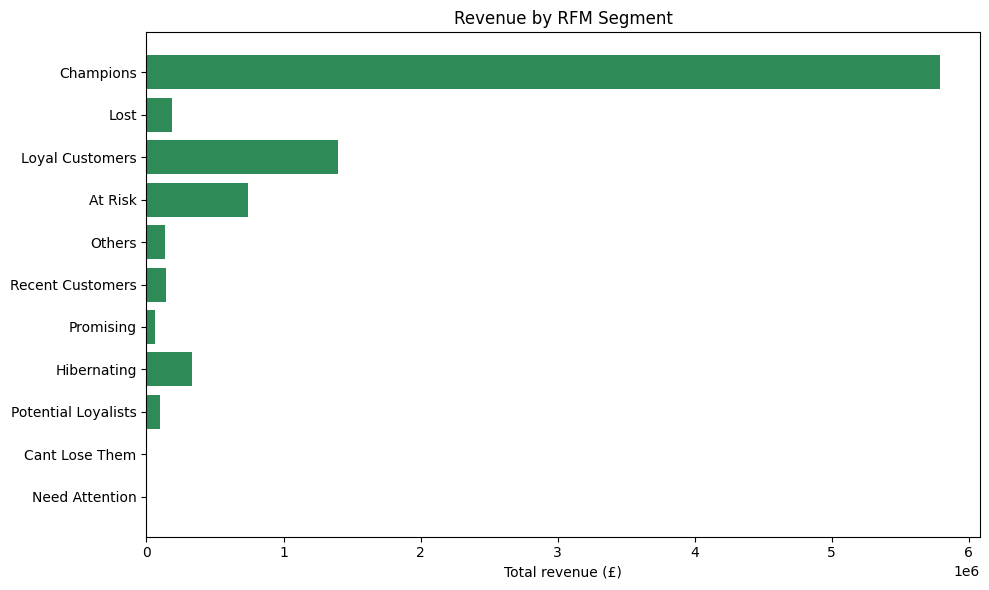

In [8]:
# Customers per segment
plot_seg = segment_summary.sort_values("Customers", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_seg["Segment"].astype(str), plot_seg["Customers"], color="steelblue")
plt.xlabel("Number of customers")
plt.title("Customers by RFM Segment")
plt.tight_layout()
plt.show()

# Revenue share by segment
plt.figure(figsize=(10, 6))
plt.barh(
    plot_seg["Segment"].astype(str),
    plot_seg["Total_Revenue"],
    color="seagreen",
)
plt.xlabel("Total revenue (£)")
plt.title("Revenue by RFM Segment")
plt.tight_layout()
plt.show()

,R_Score,F_Score,M_Score
Segment,,,
Champions,4.58,4.70,4.64
Recent Customers,4.31,1.56,1.97
Loyal Customers,3.63,3.77,3.68
Potential Loyalists,3.00,1.61,3.45
Promising,3.00,1.50,1.46
Others,2.87,3.21,1.72
At Risk,1.75,3.66,3.75
Hibernating,1.55,1.55,3.38
Lost,1.33,1.45,1.41


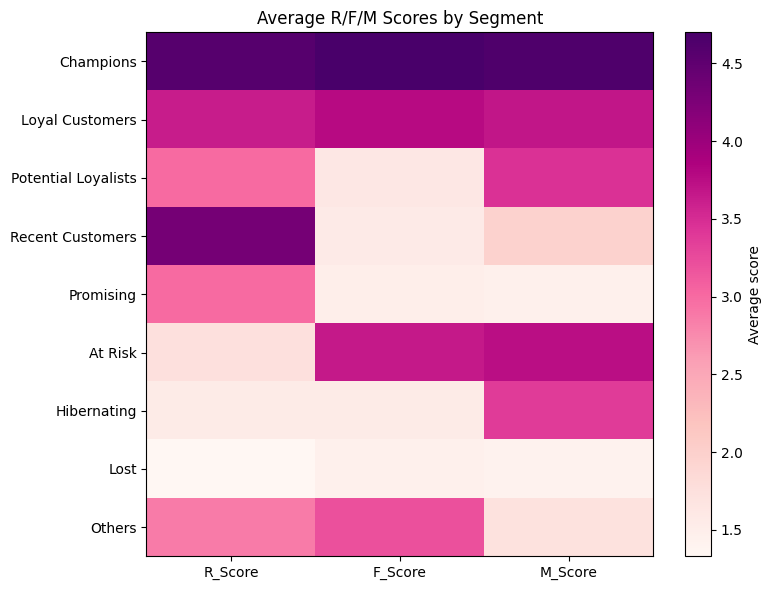

In [15]:
# Average R, F, M by segment (heatmap-style table)
segment_avg_scores = (
    rfm_scored.groupby("Segment", observed=False)[["R_Score", "F_Score", "M_Score"]]
    .mean()
    .round(2)
)

# Keep only segments with at least one customer (avoids NaN rows in heatmap)
active_segments = rfm_scored["Segment"].value_counts().index
segment_avg_scores = segment_avg_scores.loc[segment_avg_scores.index.isin(active_segments)]

display(segment_avg_scores.sort_values("R_Score", ascending=False))

# Heatmap — non-null rows only
heatmap_data = segment_avg_scores.dropna(how="all").astype(float)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdPu")
ax.set_xticks(range(heatmap_data.shape[1]))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index.astype(str))
plt.colorbar(im, label="Average score")
plt.title("Average R/F/M Scores by Segment")
plt.tight_layout()
plt.show()

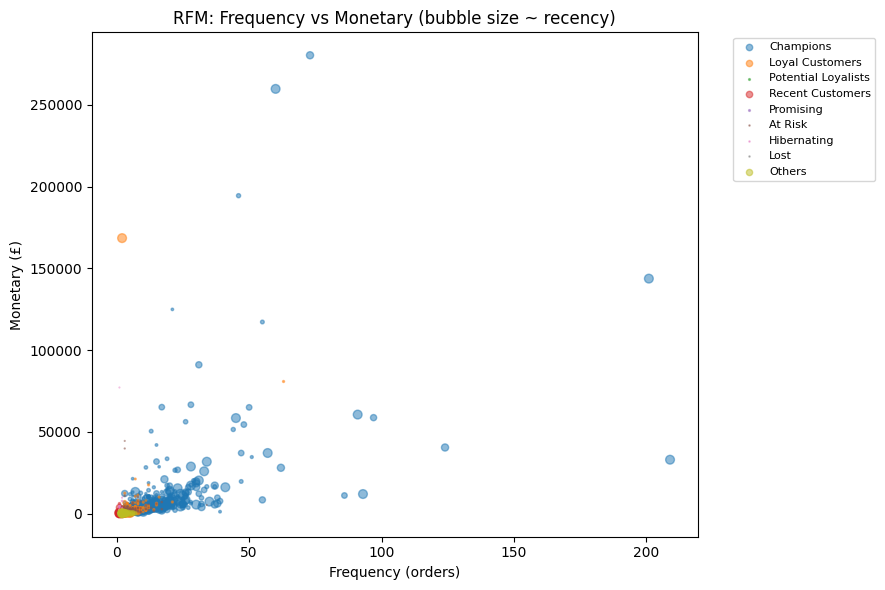

In [11]:
# Scatter: Frequency vs Monetary (point size = Recency inverted)
sample = rfm_scored.copy()
sample["Recency_Size"] = 1 / (sample["Recency"] + 1)

plt.figure(figsize=(9, 6))
for seg in segment_order:
    subset = sample[sample["Segment"] == seg]
    if len(subset) == 0:
        continue
    plt.scatter(
        subset["Frequency"],
        subset["Monetary"],
        s=subset["Recency_Size"] * 80,
        alpha=0.5,
        label=seg,
    )

plt.xlabel("Frequency (orders)")
plt.ylabel("Monetary (£)")
plt.title("RFM: Frequency vs Monetary (bubble size ~ recency)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Sample customers per segment

In [12]:
cols = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "R_Score",
    "F_Score",
    "M_Score",
    "RFM_Score",
    "Segment",
]

for seg in segment_order:
    subset = rfm_scored[rfm_scored["Segment"] == seg]
    if len(subset) == 0:
        continue
    print(f"\n--- {seg} (n={len(subset):,}) — top 5 by Monetary ---")
    display(subset.nlargest(5, "Monetary")[cols])


--- Champions (n=957) — top 5 by Monetary ---


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
1689,14646,2,73,280206.02,5,5,5,555,Champions
4201,18102,1,60,259657.30,5,5,5,555,Champions
3728,17450,8,46,194390.79,5,5,5,555,Champions
1879,14911,1,201,143711.17,5,5,5,555,Champions
55,12415,24,21,124914.53,4,5,5,455,Champions



--- Loyal Customers (n=764) — top 5 by Monetary ---


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
3008,16446,1,2,168472.50,5,3,5,535,Loyal Customers
2702,16029,39,63,80850.84,3,5,5,355,Loyal Customers
324,12744,52,7,21279.29,3,5,5,355,Loyal Customers
269,12678,42,12,17628.46,3,5,5,355,Loyal Customers
152,12536,43,3,12601.83,3,3,5,335,Loyal Customers



--- Potential Loyalists (n=101) — top 5 by Monetary ---


...

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,5,115,Hibernating
196,12590,211,2,9864.26,1,2,5,125,Hibernating
73,12435,80,2,7829.89,2,2,5,225,Hibernating
278,12688,114,1,4873.81,2,1,5,215,Hibernating
329,12752,81,1,4366.78,2,1,5,215,Hibernating



--- Lost (n=821) — top 5 by Monetary ---


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
746,13338,158,1,487.02,2,1,2,212,Lost
985,13675,151,2,486.82,2,2,2,222,Lost
237,12639,239,1,486.10,1,1,2,112,Lost
2021,15109,246,1,484.95,1,1,2,112,Lost
888,13531,205,2,483.80,1,2,2,122,Lost



--- Others (n=429) — top 5 by Monetary ---


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
3730,17453,18,2,486.72,4,3,2,432,Others
2159,15287,22,2,486.69,4,3,2,432,Others
3412,16999,23,2,484.82,4,3,2,432,Others
3061,16518,61,2,484.32,3,3,2,332,Others
1907,14958,147,3,483.73,2,3,2,232,Others


## Export RFM table (optional)

In [13]:
# Full customer RFM export
rfm_export = rfm_scored.sort_values("Monetary", ascending=False)
rfm_export.to_csv("rfm_customer_segments.csv", index=False)
print(f"Saved: rfm_customer_segments.csv ({len(rfm_export):,} customers)")

rfm_export.head()

Saved: rfm_customer_segments.csv (4,338 customers)


,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,R_Score,F_Score,M_Score,RFM_Score,RFM_Sum,Segment
1689,14646,2,73,280206.02,3838.438630,5,5,5,555,15,Champions
4201,18102,1,60,259657.30,4327.621667,5,5,5,555,15,Champions
3728,17450,8,46,194390.79,4225.886739,5,5,5,555,15,Champions
3008,16446,1,2,168472.50,84236.250000,5,3,5,535,13,Loyal Customers
1879,14911,1,201,143711.17,714.980945,5,5,5,555,15,Champions


## Insights & business recommendations

### Key findings
- **4,338 customers** in RFM base (cleaned data with valid `CustomerID`).
- **Champions (~22% of customers) generate ~65% of revenue** — extreme concentration; a small group drives most value.
- **Loyal Customers (~18% of customers, ~16% of revenue)** — strong second tier; worth retention investment.
- **At Risk (~10% of customers, ~8% of revenue)** — historically valuable but not recent; highest-priority win-back list.
- **Lost (~19% of customers, only ~2% of revenue)** — many one-time, low-spend buyers; cheap reactivation or reduce marketing cost.
- **Hibernating (~6% of customers, ~4% of revenue)** — spent meaningfully before but inactive; targeted offers may work.
- **Recent Customers & Potential Loyalists** — recent but low frequency; focus on **2nd and 3rd purchase** journeys.
- **Cant Lose Them / Need Attention** — no customers matched rules; consider tuning thresholds later.

### Business recommendations

| Segment | Recommended action |
|---------|-------------------|
| **Champions** | VIP rewards, early access, referral programme; assign account care for top monetary accounts. |
| **Loyal Customers** | Cross-sell from hero categories (Kitchen, Home Decor, Bags); loyalty points; personalised category offers. |
| **At Risk** | Urgent win-back email/SMS (“We miss you”); time-limited discount; highlight new bestsellers. |
| **Cant Lose Them** *(if identified after rule tuning)* | Personal outreach before churn; do not use mass discount blasts. |
| **Hibernating** | Seasonal reactivation (Q3–Q4); bundle offers aligned with past category purchases. |
| **Recent Customers / Potential Loyalists** | Post-purchase flow: thank-you → review request → 2nd-order incentive within 30–60 days. |
| **Promising** | Test upsell on checkout; introduce mid-tier products from core categories. |
| **Lost** | Low-cost email only; suppress from expensive paid ads unless testing a win-back campaign. |
| **Others** | Review manually; refine RFM rules or sub-segment by category/country. |

### Strategic priorities
1. **Protect Champions + Loyal (~40% of customers, ~80%+ of revenue)** — retention budget should focus here first.
2. **Win-back At Risk + Hibernating** — smaller groups but better ROI than chasing Lost customers.
3. **Convert Recent / one-time buyers** — largest growth lever if you reduce the ~19% Lost share over time.
4. **Align campaigns with category strategy** — e.g. Champions who bought Kitchen/Home Decor get different creatives than Bag-only buyers (merge RFM export with category data).
5. **Review bulk B2B outliers** — top Monetary customers may be wholesalers; treat separately so they do not distort mass-market CRM rules.

### Data notes
- Recency is measured to **end of dataset (Dec 2011)**, not today — interpret “At Risk” as inactive **within that year’s window**.
- Use exported **`rfm_customer_segments.csv`** for email lists and CRM imports.